Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
       open      high       low     close        volume merge_date
0  93347.59  94960.91  92743.63  94383.59   6871.738482 2025-01-01
1  94383.59  97776.99  94177.00  96903.19  10912.473840 2025-01-02
2  96905.48  98969.92  96016.63  98136.51   9021.885382 2025-01-03
3  98139.85  98761.02  97516.65  98209.85   2742.089606 2025-01-04
4  98209.85  98814.00  97250.00  98345.33   2377.921759 2025-01-05
X shape: (1, 249, 1)
Y shape: (1, 63, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 128)            │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_2 (RepeatVector)  │ (None, 63, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 63, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 63, 1)          │           129 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,273 (774.50 KB)

 Trainable params: 198,273 (774.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
1/1 - 5s - 5s/step - loss: 0.6072 - mae: 0.7714
Epoch 2/200
1/1 - 0s - 200ms/step - loss: 0.3597 - mae: 0.5883
Epoch 3/200
1/1 - 0s - 163ms/step - loss: 0.1688 - mae: 0.3882
Epoch 4/200
1/1 - 0s - 169ms/step - loss: 0.0458 - mae: 0.1593
Epoch 5/200
1/1 - 0s - 176ms/step - loss: 0.1023 - mae: 0.2861
Epoch 6/200
1/1 - 0s - 163ms/step - loss: 0.1069 - mae: 0.2951
Epoch 7/200
1/1 - 0s - 170ms/step - loss: 0.0510 - mae: 0.1892
Epoch 8/200
1/1 - 0s - 203ms/step - loss: 0.0289 - mae: 0.1305
Epoch 9/200
1/1 - 0s - 277ms/step - loss: 0.0349 - mae: 0.1398
Epoch 10/200
1/1 - 0s - 176ms/step - loss: 0.0473 - mae: 0.1774
Epoch 11/200
1/1 - 0s - 177ms/step - loss: 0.0546 - mae: 0.1974
Epoch 12/200
1/1 - 0s - 185ms/step - loss: 0.0541 - mae: 0.1970
Epoch 13/200
1/1 - 0s - 202ms/step - loss: 0.0474 - mae: 0.1810
Epoch 14/200
1/1 - 0s - 246ms/step - loss: 0.0377 - mae: 0.1539
Epoch 15/200
1/1 - 0s - 288ms/step - loss: 0.0286 - mae: 0.1261
Epoch 16/200
1/1 - 0s - 316ms/step - loss: 0.0232 - 

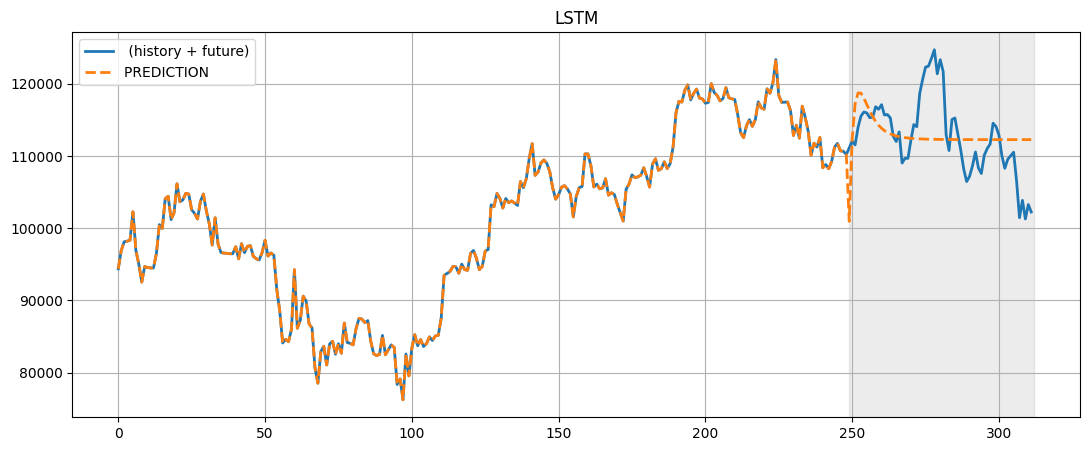

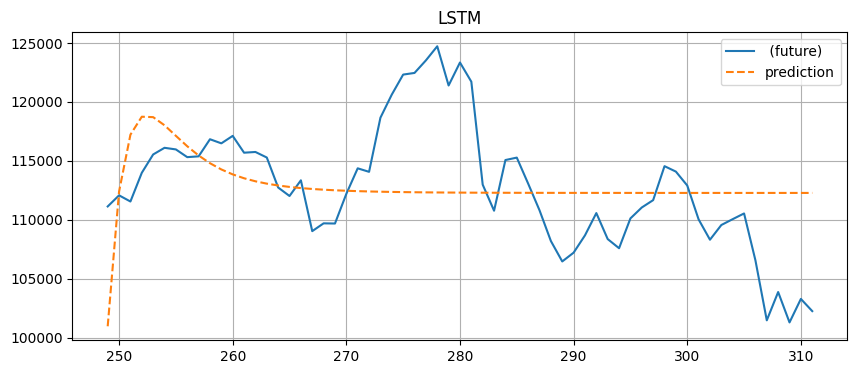

MSE: 29424205.1262   |   MAE: 4138.5170


In [5]:
# -*- coding: utf-8 -*-
# ============================================
#   LSTM Time-Series Forecasting (Real Data)
#     HISTORY = 249, FORECAST = 63
#     Series length = 312
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed

# ============================================================
# 1) خواندن دیتای واقعی از گوگل درایو
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(
    '/content/drive/MyDrive/data/FINAL SELECTED DATA SET/Bitcoin.csv',
    sep=';',
    parse_dates=['merge_date'],
    dayfirst=True
)

print(df.head())

# ============================================================
# 2) انتخاب ستون close (درصورت نیاز می‌توان ستون دیگری انتخاب کرد)
# ============================================================

series = df['close'].values.astype(float)

if len(series) != 312:
    raise ValueError(f"طول سری باید ۳۱۲ باشد، اما دیتای شما: {len(series)}")

# ============================================================
# 3) Scale داده بین 0 و 1
# ============================================================
scaler = MinMaxScaler()
series_scaled = scaler.fit_transform(series.reshape(-1,1)).flatten()

HISTORY = 249
FORECAST = 63
TOTAL = HISTORY + FORECAST

# ============================================================
# 4) ساخت ورودی و خروجی (فقط یک نمونه کامل!)
# ============================================================

X = series_scaled[:HISTORY]                 # 249
Y = series_scaled[HISTORY: TOTAL]           # 63

X = X.reshape(1, HISTORY, 1)
Y = Y.reshape(1, FORECAST, 1)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

# ============================================================
# 5) تعریف مدل LSTM (Encoder-Decoder)
# ============================================================

model = Sequential([
    LSTM(128, activation='tanh', input_shape=(HISTORY, 1)),
    RepeatVector(FORECAST),
    LSTM(128, activation='tanh', return_sequences=True),
    TimeDistributed(Dense(1))
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# ============================================================
# 6) به دلیل اینکه فقط یک نمونه داریم، آموزش کامل ممکن نیست
#    پس از همان نمونه برای چند epoch جهت فیت شدن استفاده می‌کنیم
# ============================================================

history = model.fit(
    X, Y,
    epochs=200,
    batch_size=1,
    verbose=2
)

# ============================================================
# 7) پیش‌بینی
# ============================================================

pred_scaled = model.predict(X)[0].flatten()
pred = scaler.inverse_transform(pred_scaled.reshape(-1,1)).flatten()

# دادهٔ واقعی future
actual = scaler.inverse_transform(Y[0].flatten().reshape(-1,1)).flatten()

# ============================================================
# 8) رسم نمودار تاریخچه + آینده واقعی + پیش‌بینی آینده
# ============================================================

history_real = series[:HISTORY]
future_real  = series[HISTORY:TOTAL]

pred_full = np.concatenate([history_real, pred])
real_full = np.concatenate([history_real, future_real])

plt.figure(figsize=(13,5))
plt.plot(real_full, label=' (history + future)', linewidth=2)
plt.plot(pred_full, '--', label='PREDICTION ', linewidth=2)
plt.axvspan(HISTORY, TOTAL, color='gray', alpha=0.15)
plt.title("LSTM")
plt.legend()
plt.grid()
plt.show()

# ============================================================
# 9) رسم زوم آینده
# ============================================================

t_future = np.arange(HISTORY, TOTAL)

plt.figure(figsize=(10,4))
plt.plot(t_future, future_real, label=' (future)')
plt.plot(t_future, pred, '--', label='prediction')
plt.title("LSTM")
plt.legend()
plt.grid()
plt.show()

# ============================================================
# 10) محاسبه خطا
# ============================================================

mse = mean_squared_error(future_real, pred)
mae = mean_absolute_error(future_real, pred)
print(f"MSE: {mse:.4f}   |   MAE: {mae:.4f}")
